# Домашнее задание 3. Детекция объектов

Сыграем в квиддич? Или лучше в карты?

В этом дз вам предстоит написать практически с нуля архитектуру для детекции, а также воспользоваться готовым решением. На выбор даётся два датасета, отличаются они только картинками. Форматы, баллы - все одинаково.

Первый вариант это датасет по кадрам игры в квиддич из Гарри Поттера. Если вы забыли правила, то нажмите [сюда](https://harrypotter.fandom.com/ru/wiki/%D0%9A%D0%B2%D0%B8%D0%B4%D0%B4%D0%B8%D1%87). Вы научитесь искать и выделять на фотографиях бладжеры, квоффл и снитч.

Второй вариант это датасет с игральными картами. Если вы забыли что такое карты, то нажмите [сюда](https://ru.wikipedia.org/wiki/%D0%98%D0%B3%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B5_%D0%BA%D0%B0%D1%80%D1%82%D1%8B). Вы научитесь искать и выделять на фотографиях несколько типов карт.

Оба варианта содержат около 300 картинок, данные хранятся в xml в формате PascalVOC. Есть малые отличия, но ничего страшного.


Если с самописным детектором совсем не получается, то можно после создания датасетов перейти к концу, где обучается готовый, с ним будет проще :)

# Notes

Дз проверялось на работоспособность в colab. Не гарантируется, что будет работать на чем-то другом, и точно не будет работать из коробки на Windows.

По вопросам формулировок (не ошибок торча!), в случае отсутствия ответа в общем чате (поиск по чату позволяет проверить), можно написать в него с тегом @markblumenau.

## Данные

Скачайте один из датасетов на свой вкус и начните работу с ним.
Разметка находится в xmls папке, картинки в images.

In [1]:
import os
import urllib.request
import zipfile

url = "https://github.com/markblumenau/hw3_iad_dl/raw/main/cards/data.zip"

if not os.path.exists("data"):
    if not os.path.exists("data.zip"):
        urllib.request.urlretrieve(url, "data.zip")
    with zipfile.ZipFile("data.zip") as archive:
        archive.extractall(".")

# Задача 1. 0.5 балла.

Ниже написан код для стандартного Dataset из библиотеки pytorch. Dataset требует реализации `__getitem__` и `__len__` методов. Далее эти методы будут использованы для формирования батчей для обучения. Поскольку читать придется из xml файлов, нужно перед этим дописать функцию get_xml_data, чтобы по названию картинки подтягивать аннотации.

In [2]:
import torch
from xml.etree import ElementTree as ET
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from pathlib import Path
import glob
import numpy as np
from PIL import Image
import torchvision
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm
from torch import nn
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

Функции можно и нужно передать некий class_dict. Он есть и при инициализации датасета ниже. С его помощью можно название класса превратить в int. Далее подразумевается, что класс идёт как int.

In [3]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    # get smth like ZZZ/YYY/XXXXXX.jpg -> XXXXXX
    filename = image_name.replace("\\", "/").split("/")[-1].split(".")[0]
    # read xml
    tree = ET.parse(str(root) + xml_prefix + filename + ".xml")
    treeroot = tree.getroot()
    # iterate over bboxes
    bboxes = []
    for member in treeroot.findall("object"):
        # you need: xmin ymin xmax ymax, class in dict
        bndbox = member.find("bndbox")
        res = [
            float(bndbox.find("xmin").text),
            float(bndbox.find("ymin").text),
            float(bndbox.find("xmax").text),
            float(bndbox.find("ymax").text),
            class_dict[member.find("name").text],
        ]

        bboxes.append(res)

    return bboxes

In [4]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42):
        self.root = Path(root)
        self.transform = transform

        assert self.root.is_dir(), f"No data at `{root}`"

        self.filenames = np.array(glob.glob(root + "/images/*"))
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())

        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}

        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))

        # Train/test split
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = np.array(Image.open(fname).convert("RGB"))
        bboxes = get_xml_data(fname, self.root, self.class_dict)

        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_xml_data(fname, self.root, self.class_dict)

    def __len__(self):
        return len(self.filenames)

Ниже определяем стандартные нормализации и приведение размера к 512x512.


In [5]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

In [6]:
train_ds = PascalDataset(root="./data/", transform=train_transform, train=True)
test_ds = PascalDataset(root="./data/", transform=test_transform, train=False)

# Задача 2. 1 балл.

Теперь, когда мы загрузили данные, хорошо бы посмотреть на них, прежде чем обучать какие-либо модели. Напишите функцию `visualize`, которая принимает списки изображений и прямоугольников в качестве входных данных и рисует эти прямоугольники на изображениях.

В датасете есть class_dict_inv, который позволит вам сделать обратное преобразование: int, содержащий класс, в строку с названием.


Полезные функции:
* [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) -- легко создавать несколько изображений в одной pyplot figure
* [ax.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) -- отображение графиков (не забудьте откатить нормализацию)
* [ax.text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html), [patches.Rectangle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) -- для рисования прямоугольников и текста с аннотацией

In [7]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(
        2, len(images) // 2 + len(images) % 2, figsize=(10, 8), dpi=100
    )

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break

        img = images[i].permute(1, 2, 0).numpy() * np.array(std) + np.array(mean)
        img = np.clip(img, 0, 1)
        ax.imshow(img)

        for bbox in bboxes[i]:
            xmin, ymin, xmax, ymax, cls = bbox
            ax.add_patch(
                Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color="red")
            )
            ax.text(
                xmin, ymin, train_ds.class_dict_inv[int(cls)],
                color="white", fontsize=8, backgroundcolor="red",
            )

    fig.tight_layout()
    plt.show()

У вас должно получиться что-то похожее на изображения для датасета с масками:

![image](https://gcdnb.pbrd.co/images/n8BnhhfCgYnQ.png)

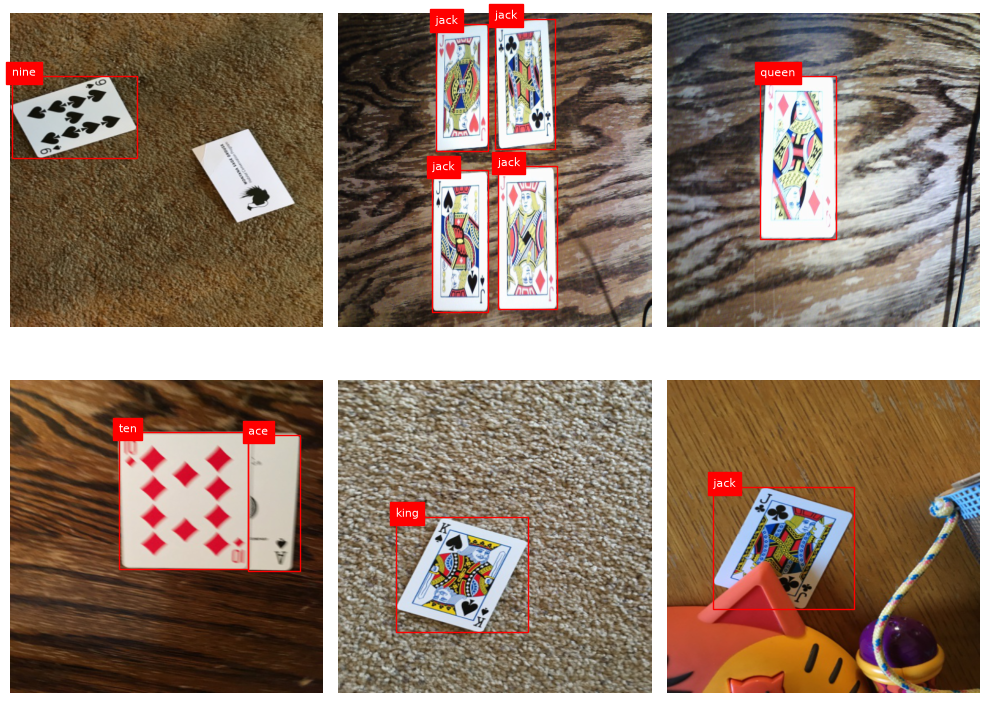

In [8]:
out = [train_ds[i] for i in range(6)]
visualize([o["image"] for o in out], [o["bboxes"] for o in out])

# Задача 3. 3 балла.
## YOLO-like детектор

Сейчас нам предстоить реализовать детектор, похожий на YOLO. Это один из самых простых детекторов с точки зрения реализации. YOLO описан в статье: [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640). Здесь мы его немного изменим и упростим. Будем использовать ResNet для извлечения признаков. На выходе мы будем получать карту признаков размера 16x16.

We convert lists of bounding boxes to the target downsampled grid. For this we

* compute centers of bounding boxes ($c_x, c_y$)
* change center coordinates (offset from the top left corner for each corresponding grid cell on a small grid)
* normalize box height and with to $[0, 1]$
* fill the target grid with values

## Задача 3.1. 1 балл.

Первым делом нам нужно реализовать collate function. Это функция позволит нам кастомизировать, как именно батч конструируется из примеров (смотрите [pytorch docs](https://pytorch.org/docs/stable/data.html#dataloader-collate-fn) для деталей).

Это функция должна принять на вход лист прямоугольников и сгенерировать тензор размера Bx16x16x6. Первая размерность - это количество примеров в батче. Далее идут две пространственные размерности, это сетка 16 на 16. 

В каналах у нас будут записаны:
* Сдвиги центра bbox относительно начала клеточки (клеточка это "пиксель" на изображении 16 на 16 на выходе сети). Записаны эти сдвиги будут в клеточку, к которой относятся. 2 канала (X, Y)
* Нормализованные ширина и высота bbox. 2 канала (W, H)
* Confidence сетки. Им мы будем пользоваться, чтобы фильтровать уверенность сетки в наличии bbox в данной клетке. Таргет содержит 1 там, где bbox есть, и 0 иначе. 1 канал
* Класс детекции (тот самый int, полученный из строки с названием)

In [9]:
def collate_fn(batch, downsample=32):
    imgs, batch_boxes = map(list, (zip(*[(b["image"], b["bboxes"]) for b in batch])))

    imgs = torch.stack(imgs)
    b, _, h, w = imgs.shape

    target = imgs.new_zeros(b, 6, h // downsample, w // downsample)

    # Add sample index to targets
    for i, boxes in enumerate(batch_boxes):
        if len(boxes) == 0:
            continue

        xmin, ymin, xmax, ymax, classes = map(
            torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)
        )

        # Нормализуйте ширину и высоту, поделив на ширину и высоту исходного изображения
        x_cell = w / (w // downsample)  # размер клетки по X в пикс
        y_cell = h / (h // downsample)  # размер клетки по Y в пикс
        w_box = (xmax - xmin) / w  # ширина бокса отнормированная
        h_box = (ymax - ymin) / h  # высота бокса отнормированная

        # Посчитайте координаты центра и сдвиги
        cx = (xmin + xmax) / 2  # координаты центра в исходных координатах
        cy = (ymin + ymax) / 2
        cx_idx = (cx / x_cell).long().clamp(0, target.shape[-1] - 1)  # индекс центра на карте признаков
        cy_idx = (cy / y_cell).long().clamp(0, target.shape[-2] - 1)

        cx_box = cx / x_cell - cx_idx  # сдвиги относительно cx_idx
        cy_box = cy / y_cell - cy_idx

        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}

Ниже вы можете увидеть пример, как выглядит решетка размера 16 на 16 на исходном изображении:

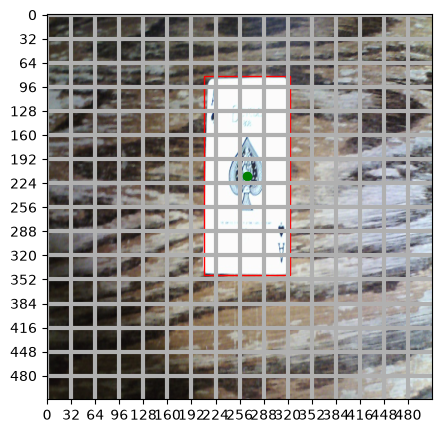

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
i = 20

img = train_ds[i]["image"].permute(1, 2, 0) * torch.tensor(std).view(
    1, 1, -1
) + torch.tensor(mean).view(1, 1, -1)
bboxes = torch.tensor(train_ds[i]["bboxes"])

ax.imshow(img)
loc = plt.matplotlib.ticker.MultipleLocator(base=32)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
ax.grid(which="major", axis="both", linestyle="-", linewidth=3)

for bbox in bboxes:
    xmin, ymin, xmax, ymax = bbox[:-1]
    w = xmax - xmin
    h = ymax - ymin
    with_mask = bbox[-1]
    ax.add_patch(Rectangle((xmin, ymin), w, h, fill=False, color="red"))

cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

ax.scatter(cx, cy, color="green", marker="o")

plt.show()

## Задача 3.2. 0.5 балла.

Выход нашей сетки будет несколько больше, чем Bx16x16x6. Почему? 

Мы решаем задачу, где классов больше одного. Вспомним прошлое дз: target был одним числом, но выход сетки содержал длинный-длинный вектор, из которого мы получали вероятность принадлежности к тому или иному классу. Здесь то же самое, но как бы в двумерии: у каждой клеточки из этих 16*16 будет свой вектор длины C, который мы будем использовать для определения класса.

Реализуйте обратное относительно collate_fn преобразования, чтобы декодировать выход нейронной сети. Применив функцию decode_prediction к выходу collate function вы должны получить изначальный набор прямоугольников с корректными размерами и координатами, а также классами. Применив к выходу нейросети мы тоже должны получить набор прямоугольников и тоже с корректными классами. 

То есть, нужно проделать операции из collate_fn в обратную сторону, но учесть, что у неройнки выход будет чуть длиннее, и там мы должны брать argmax для определения класса.

Hint: в target classes идут в конце. В нейронке они тоже будут в конце, но их будет больше 1. Можно проверять число каналов пришедшего объекта, если оно 6, то перед нами target и надо брать значение, которое записано в клеточке. Иначе (каналов больше 6) перед нами выход нейронки, и надо брать самый вероятный из них.

In [11]:
def decode_prediction(pred, upsample=32, threshold=0.7):
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample

    is_target = c == 6
    conf = pred[:, 4]
    mask = (conf > 0.5) if is_target else (conf > threshold)

    results = []
    for i in range(b):
        boxes = []
        for row, col in mask[i].nonzero(as_tuple=False).tolist():
            cx_box, cy_box = pred[i, 0, row, col], pred[i, 1, row, col]
            w_box, h_box = pred[i, 2, row, col], pred[i, 3, row, col]

            cx = (col + cx_box) * upsample
            cy = (row + cy_box) * upsample
            box_w = w_box * img_w
            box_h = h_box * img_h

            xmin, ymin = cx - box_w / 2, cy - box_h / 2
            xmax, ymax = cx + box_w / 2, cy + box_h / 2

            cls = int(pred[i, 5, row, col].item()) if is_target else int(pred[i, 5:, row, col].argmax().item())

            boxes.append([xmin.item(), ymin.item(), xmax.item(), ymax.item(), cls])
        results.append(boxes)

    return results

## Задача 3.3. 1 балл.
Реализуйте модель. Первым делом примените первые 4 блока (до layer4 включительно) ResNet50. Далее добавьте несколько блоков (Conv2D, BatchNorm2D, ReLU). Постепенно уменьшайте количество каналов до 5+C, а размер изображения до 16 на 16. Например, 2048 -> 512 -> 128 -> 32 -> 5+C, где С - количество классов в вашем датасете. Размер ядра при этом 3, паддинг 1. Но вариантов много, попробуйте разные! **Последним слоем обязательно должна быть свертка.** Так как все значения, которые мы предсказываем, находятся в отрезке от 0 до 1 (благодаря нормировке с клеточками), мы после финальной свертки еще применим сигмоиду. Для классов в такой постановке это не навредит.

Если будете фантазировать, то для получения правильного размера изображения после сети не стесняйтесь применять слои с фильтрами больше 3.

In [12]:
C =  len(train_ds.class_dict)  # Количество классов в вашем датасете, хоть руками посчитайте, хоть подтяните из словаря классов


class Detector(nn.Module):
    def __init__(self):
        super().__init__()
        model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(
            model.conv1, model.bn1, model.relu, model.maxpool,
            model.layer1, model.layer2, model.layer3, model.layer4,
        )
        self.head = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 5 + C, kernel_size=3, padding=1),
        )

    def forward(self, img):
        features = self.backbone(img)
        out = self.head(features)

        return torch.sigmoid(out)

## Задача 3.4. 0.5 балла.

Реализуйте функцию потерь.

Для этого:
* Сделайте маску, которая будет говорить о положении детектируемых объектов. Её нужно использовать с помощью masked_select (см. доки PyTorch)
* Лосс похож на оригинальный для Yolo V1 и состоит из 4 частей (reduction='sum' для всех)
    - localization loss - Мы берем MSE по координатам бокса там, где есть детектируемый объект
    - box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект
    - classification_loss - Если детектируемый объект есть, то его кросс-энтропия по его классу
    - confidence_loss - Бинарная кросс-энтропия факта наличия объекта ДЛЯ ВСЕХ пикселей. Делается отдельно для детектируемых объектов (вес 1) и для недетектируемых (вес 0.1 например, поскольку их гораздо больше, но можно экспериментировать)


* Ниже есть assert. Если вы экспериментируете с лоссом, он не будет проходить, не обращайте на него внимание. Если будете делать описанное выше, то учтите reduction. Бинарная кросс-энтропия вызывается через BCELoss. Параметр C используется для задачи числа классов. assert написан для 3 классов, в задаче с картами их 6. Подумайте как зависит индексация от параметра C и используйте его.

In [13]:
import torch.nn.functional as F


def special_loss(pred, target, check=False, C=C):
    obj_mask = target[:, 4] == 1

    pred_xy = pred[:, 0:2].permute(0, 2, 3, 1)[obj_mask]
    target_xy = target[:, 0:2].permute(0, 2, 3, 1)[obj_mask]
    localization_loss = F.mse_loss(pred_xy, target_xy, reduction="sum")

    pred_wh = pred[:, 2:4].clamp(min=0).permute(0, 2, 3, 1)[obj_mask]
    target_wh = target[:, 2:4].clamp(min=0).permute(0, 2, 3, 1)[obj_mask]
    box_loss = F.mse_loss(torch.sqrt(pred_wh), torch.sqrt(target_wh), reduction="sum")

    pred_classes = pred[:, 5:5 + C].permute(0, 2, 3, 1)[obj_mask]
    target_classes = target[:, 5][obj_mask].long()
    if pred_classes.shape[0] > 0:
        classification_loss = F.cross_entropy(pred_classes, target_classes, reduction="sum")
    else:
        classification_loss = pred.new_zeros(())

    pred_conf = pred[:, 4]
    target_conf = target[:, 4]
    weights = torch.where(obj_mask, pred.new_tensor(1.0), pred.new_tensor(0.1))
    confidence_loss = (weights * F.binary_cross_entropy(pred_conf, target_conf, reduction="none")).sum()

    if not check:
        return localization_loss + box_loss + classification_loss + confidence_loss

    else:
        return localization_loss, box_loss, classification_loss, confidence_loss

In [14]:
# localization box classification confidence - возвращаются в таком порядке, можно сравнить
assert special_loss(torch.zeros((10, 8, 16, 16)), torch.ones((10, 8, 16, 16)), check=True, C=3) == (torch.tensor(5120.), torch.tensor(5120.), torch.tensor(2812.4465), torch.tensor(256000.))

# Задача 4. 2 балла.

Обучите вашу модель (написав цикл обучения), и покажите что она работает (скорее всего, объекты найдутся на 1-2 картинках).

In [15]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn)

In [16]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(21)
EPOCHS = 15  # Harry Potter 20, Cards 15
model = Detector().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for e in range(EPOCHS):
    t_epoch = time.time()
    epoch_losses = []
    for batch in loader:
        images = batch["image"].to(device)
        target = batch["target"].to(device)

        opt.zero_grad()
        pred = model(images)
        loss = special_loss(pred, target, C=C)
        loss.backward()
        opt.step()

        epoch_losses.append(loss.item())

    print(f"Epoch {e} done in {time.time() - t_epoch:.1f}s; Train loss {np.mean(epoch_losses):.3f};")

Epoch 0 done in 460.7s; Train loss 98.813;


Epoch 1 done in 494.2s; Train loss 45.827;


Epoch 2 done in 452.0s; Train loss 38.692;


Epoch 3 done in 449.4s; Train loss 35.634;


Epoch 4 done in 511.8s; Train loss 32.136;


...

Epoch 10 done in 486.5s; Train loss 26.421;


Epoch 11 done in 484.8s; Train loss 26.064;


Epoch 12 done in 477.1s; Train loss 25.276;


Epoch 13 done in 503.0s; Train loss 24.740;


Epoch 14 done in 518.8s; Train loss 24.311;


Запустим обученный детектор на тестовых изображениях:

In [17]:
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [18]:
# Нужно сделать предсказание и переложить результат на cpu

model.eval()
with torch.no_grad():
    pred = model(batch["image"].to(device)).cpu()

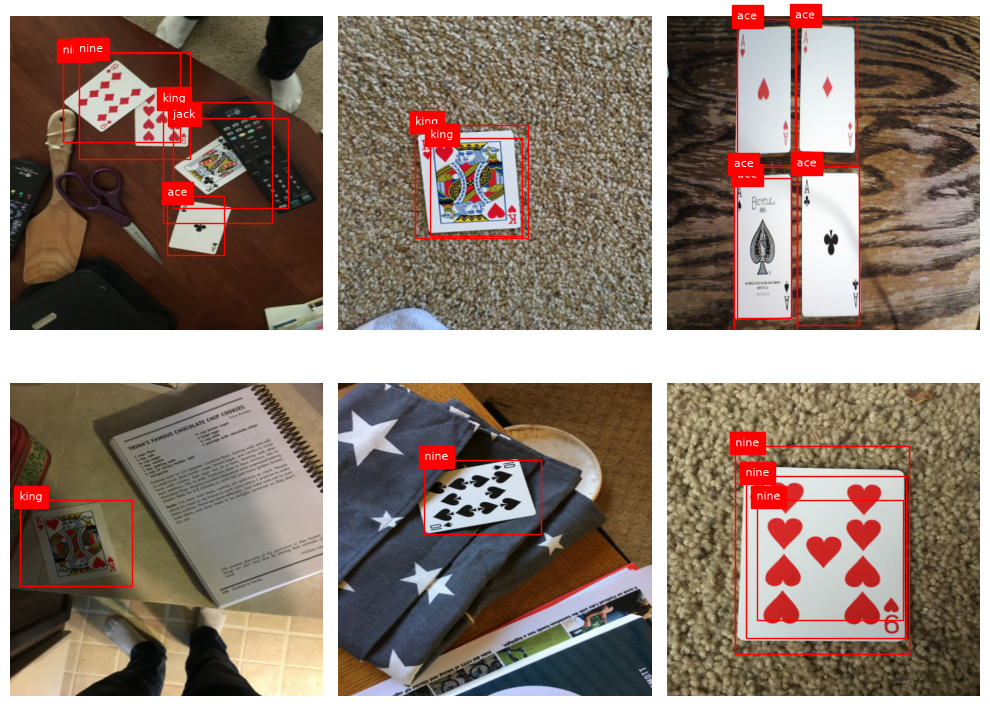

In [19]:
# Сделайте визуализацию. Поиграйтесь с threshold, скорее всего нужно понизить до ~0.1

decoded = decode_prediction(pred, threshold=0.1)
visualize(list(batch["image"]), decoded)

Результат сильно так себе, да? Есть множество вариантов улучшений, самый простой из которых это приделать к выходу [NMS](https://paperswithcode.com/method/non-maximum-suppression#:~:text=Non%20Maximum%20Suppression%20is%20a,below%20a%20given%20probability%20bound.). Если хочется, можно почитать про YOLO v1 [тут](https://arxiv.org/abs/1506.02640).

# Задача 5. 3.5 балла.

Займёмся более простыми вещами. Возьмем готовую архитектуру, обучим её на наших данных и посмотрим.

Для этого будем использовать YOLO v8 от ultralytics.

In [20]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

CompletedProcess(args=['C:\\Users\\denict\\anaconda3\\python.exe', '-m', 'pip', 'install', '-q', 'ultralytics'], returncode=0)

## Задача 5.1. 1.5 балла.

Чтобы дальше модель обучалась одной строкой, данные нужно переложить в правильный формат. Да-да, классика перекладывания JSON. Как правильно паковать можно посмотреть [тут](https://roboflow.com/formats/yolov8-pytorch-txt).

Если коротко:
* Есть .yaml, где живут пути к папкам с картинками, количество классов и их названия
* Есть папочки train valid (их поможем вам собрать), в них две подпапки:
    - Первая images, в ней лежат картинки
    - Вторая labels, в ней лежат файлы с названиями как у картинок, но вместо расширения картинок нужен .txt, внутри формат как описан на Roboflow


In [21]:
# Делаем папочки
import shutil

for d in ["train", "valid"]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d + "/images")
    os.makedirs(d + "/labels")

Реализуйте функцию, которая принимает аннотации в изначальном формате, а возвращает их в нужном для YOLO v8. Это должен быть массив готовых строк, которые можно сразу забрасывать в файлик, добавив \n.

In [22]:
def annotation2txt(bboxes, w_im, h_im):
    lines = []
    for xmin, ymin, xmax, ymax, cls in bboxes:
        x_center = (xmin + xmax) / 2 / w_im
        y_center = (ymin + ymax) / 2 / h_im
        width = (xmax - xmin) / w_im
        height = (ymax - ymin) / h_im
        lines.append(f"{int(cls)} {x_center} {y_center} {width} {height}")

    return lines

In [23]:
# Копируем картиночки по папочкам и создаем txt файлики

for i in range(len(train_ds)):
    result = train_ds.__get_raw_item__(i)
    img_name = result[0].replace("\\", "/").split("/")[-1]

    shutil.copyfile(result[0], "./train/images/" + img_name)

    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./train/labels/" + img_name.split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

for i in range(len(test_ds)):
    result = test_ds.__get_raw_item__(i)
    img_name = result[0].replace("\\", "/").split("/")[-1]

    shutil.copyfile(result[0], "./valid/images/" + img_name)

    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./valid/labels/" + img_name.split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

In [24]:
# Собираем YAML

nc = len(train_ds.class_dict)  # Укажите число классов. Хоть руками, хоть по-умному посчитайте (см. class_dict)
names = [train_ds.class_dict_inv[i] for i in range(nc)]  # Укажите имена классов. Хоть руками, хоть по-умному посчитайте, это массив строк (см. class_dict)

with open("data.yaml", "w") as f:
    f.write(f"train: ../train/images\nval: ../valid/images\n\nnc: {nc}\nnames: {names}")

## Задание 5.2. 1.5 балла.

Обучите модель YOLO v8 самого маленького размера. Библиотека максимально friendly, от вас требуется написать две строчки. Модель нужно взять необученную!

Подсказка: подумайте зачем вам data.yaml и что такое yolov8n.yaml (не стесняйтесь гуглить)

In [25]:
import ultralytics
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.yaml")  # необученная архитектура (без .pt-весов)
yolo_results = yolo_model.train(data="data.yaml", epochs=30, imgsz=512)

New https://pypi.org/project/ultralytics/8.4.138 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.137  Python-3.13.9 torch-2.12.0+cpu CPU (AMD Ryzen 7 6800H with Radeon Graphics)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

Overriding model.yaml nc=80 with nc=6



                   from  n    params  module                                       arguments                     


...

                   ten         11         11      0.559      0.818      0.775      0.628


                  nine          9         14      0.587      0.915      0.903      0.786


                 queen         11         12      0.529        0.5      0.551        0.4


Speed: 0.8ms preprocess, 68.6ms inference, 0.0ms loss, 2.1ms postprocess per image


Results saved to C:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\runs\detect\train-2


## Задание 5.3. 0.5 балла.

Как-нибудь отрисуйте предсказания на валидационной выборке (хотя бы части из 5-10 картинок).

Здесь можно использовать костыли с параметром save=True у predict, потом прочитать их чем-нибудь, отрисовать матплотлибом. Есть варианты и получше. Дефолтный show будет пытаться показывать через opencv imshow, он в коллабе работать не будет.

image 1/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\IMG_2385.JPG: 512x384 1 king, 1 jack, 231.7ms


image 2/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\IMG_2389.JPG: 512x384 1 ace, 146.7ms


image 3/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\IMG_2402.JPG: 512x384 1 jack, 117.7ms


image 4/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\IMG_2418.JPG: 512x384 (no detections), 157.6ms


image 5/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\IMG_2430.JPG: 512x384 1 king, 1 jack, 99.0ms


...

image 35/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\cam_image29.jpg: 288x512 1 ten, 1 nine, 163.2ms


image 36/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\cam_image6.jpg: 288x512 3 nines, 260.8ms


image 37/37 c:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\valid\images\cam_image8.jpg: 288x512 4 aces, 204.7ms


Speed: 7.7ms preprocess, 177.7ms inference, 3.4ms postprocess per image at shape (1, 3, 288, 512)


Results saved to C:\Users\denict\Jupiter notebook\ML_Education\iad-deep-learning\2023\homeworks\hw3\runs\detect\predict


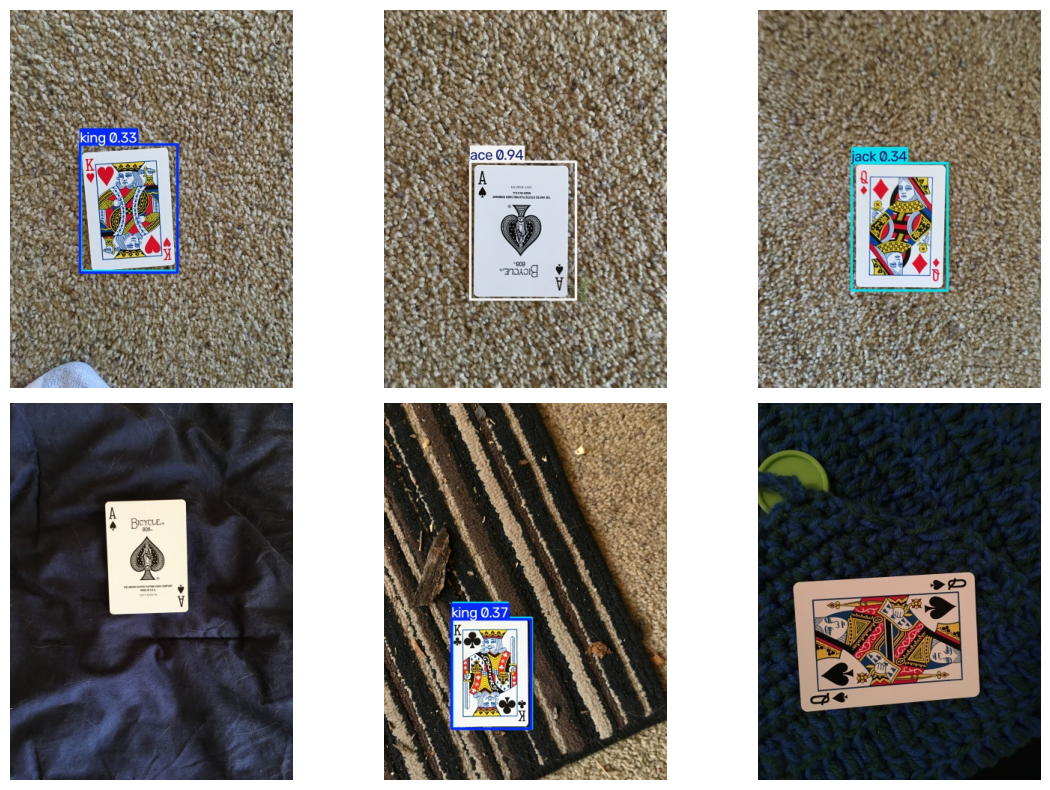

In [26]:
import glob
from PIL import Image as PILImage

predict_results = yolo_model.predict(source="valid/images", save=True, conf=0.25)
pred_dir = predict_results[0].save_dir
pred_images = sorted(glob.glob(str(pred_dir) + "/*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, path in zip(axes.flat, pred_images):
    ax.imshow(PILImage.open(path))
    ax.axis(False)
plt.tight_layout()
plt.show()